#Exploração Inicial dos Dados

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# Carregando o dataset
caminho = "../data/raw/API_SH.TBS.INCD_DS2_en_csv_v2_1949.csv"
df_raw = pd.read_csv(caminho, skiprows=4)

In [4]:
#dimensões do dataset
df_raw.shape

(266, 71)

In [5]:
# Exibindo as primeiras linhas do dataset
df_raw.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Incidence of tuberculosis (per 100,000 people)",SH.TBS.INCD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.6,4.7,1.9,0.93,5.6,4.6,3.7,8.3,NaN,NaN
1,Africa Eastern and Southern,AFE,"Incidence of tuberculosis (per 100,000 people)",SH.TBS.INCD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Incidence of tuberculosis (per 100,000 people)",SH.TBS.INCD,NaN,NaN,NaN,NaN,NaN,NaN,...,209.0,212.0,213.0,205.00,206.0,206.0,204.0,203.0,NaN,NaN
3,Africa Western and Central,AFW,"Incidence of tuberculosis (per 100,000 people)",SH.TBS.INCD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"Incidence of tuberculosis (per 100,000 people)",SH.TBS.INCD,NaN,NaN,NaN,NaN,NaN,NaN,...,418.0,403.0,390.0,373.00,371.0,379.0,383.0,373.0,NaN,NaN


In [ ]:
# Exibindo as colunas iniciais e finais do dataset
print("Colunas iniciais:", df_raw.columns[:5].tolist())
print("Colunas finais:", df_raw.columns[-5:].tolist())


In [ ]:
#Usando iloc para ecibir as colunas de iniciais e finais
print("Colunas iniciais usando iloc:", df_raw.iloc[:, :5].columns.tolist())
print("Colunas finais usando iloc:", df_raw.iloc[:, -5:].columns.tolist())

In [ ]:
#Número de paises unicos
print("Número de países únicos:", df_raw['Country Name'].nunique())

#Entender o formato que esta a tabela

Atualmente se encontra no formato wide, possuindo os anos como colunas. É necessário que o formato seja modificado para que agrupamento sejam feito possibilitando assim algumas anlises, que atualmente não é possivel.

In [6]:
#Transpor colunas de anos para formato longo
df_long = df_raw.melt(id_vars=['Country Name', 'Country Code'], 
                 var_name='Year', value_name='incidence_per_100k')

Verificações do dataset transformado

In [7]:
#Info do dataset transposto
df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 18354 entries, 0 to 18353
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country Name        18354 non-null  str   
 1   Country Code        18354 non-null  str   
 2   Year                18354 non-null  str   
 3   incidence_per_100k  6164 non-null   object
dtypes: object(1), str(3)
memory usage: 573.7+ KB


In [ ]:
#Formato do dataset transposto
formato_long = df_long.shape
print("Formato do dataset transposto:", formato_long)

Verificação se o resultado da transposição esta correto 

In [ ]:
#Numero de linhas esperadas no dataset transposto
num_paises = df_raw['Country Name'].nunique()
num_anos = len(df_raw.columns) - 2  # Subtraindo as colunas 'Country Name' e 'Country Code'
num_linhas_esperadas = num_paises * num_anos
print("Número de linhas esperadas no dataset transposto:", num_linhas_esperadas)
if formato_long[0] == num_linhas_esperadas:
    print("O número de linhas no dataset transposto está correto.")
else:
    print("O número de linhas no dataset transposto está incorreto.")

In [ ]:
#Exibindo as primeiras linhas do dataset transposto
df_long.head()

In [ ]:
#Quanidade de países únicos no dataset transposto
print("Número de países únicos no dataset transposto:", df_long['Country Name'].nunique())

In [ ]:
#exibindo as colunas iniciais e finais do dataset transposto
print("Colunas iniciais do dataset transposto:", df_long.columns[:5].tolist())
print("Colunas finais do dataset transposto:", df_long.columns[-5:].tolist())

Como temos só quatro colunas, como mostra o *shape* e pedimos para ver 5, primeiras e ultimas, as exibidas oram iguais

In [8]:
df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 18354 entries, 0 to 18353
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country Name        18354 non-null  str   
 1   Country Code        18354 non-null  str   
 2   Year                18354 non-null  str   
 3   incidence_per_100k  6164 non-null   object
dtypes: object(1), str(3)
memory usage: 573.7+ KB


A coluna years esta como str(texto) e a incidence_per_100k esta como objeto temos que trasformar elas em númericas

In [14]:
#Coluna Year e incidence_per_100k para numerico
df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce').astype('Int64')  
df_long['incidence_per_100k'] = pd.to_numeric(df_long['incidence_per_100k'], errors='coerce').astype('Float64')  
df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 18354 entries, 0 to 18353
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Name        18354 non-null  str    
 1   Country Code        18354 non-null  str    
 2   Year                17556 non-null  Int64  
 3   incidence_per_100k  5632 non-null   Float64
dtypes: Float64(1), Int64(1), str(2)
memory usage: 609.5 KB


Com as informações acima temos:
- Só existem realmente 5632 registros de incidencia. O que reflete algo normal, quando se tenta coletar dados mundiais, onde pode não ter havido realmente comunicação. Por hora vamos manter.
- Existem 17556 anos que não são nulos. Mas  sabemos que originalmente ao derreter para cria essa versão houveram cyears atribuido com "Indicator Name " e "Unnamed:70", que são propriamente texto e devem se limpos

In [15]:
#Removendo os nulos da coluna Year
df_long_clean = df_long.dropna(subset=['Year'])
df_long_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 17556 entries, 532 to 18087
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Name        17556 non-null  str    
 1   Country Code        17556 non-null  str    
 2   Year                17556 non-null  Int64  
 3   incidence_per_100k  5632 non-null   Float64
dtypes: Float64(1), Int64(1), str(2)
memory usage: 583.0 KB


In [ ]:
#Exibindo as Linhas iniciais 
df_long_clean.head()


In [ ]:
#Exibindo as linhas finais do dataset
df_long_clean.tail()  

In [17]:
#Validação do dataset limpo
print(df_long_clean['incidence_per_100k'].describe()) #Estatísticas descritivas da coluna incidence_per_100k
print("Países únicos:", df_long_clean['Country Name'].nunique()) #Número de países únicos
print("Anos únicos:", df_long_clean['Year'].nunique()) #Número de anos únicos   
print("Shape:", df_long_clean.shape) #Formato do dataset limpo


count        5632.0
mean     142.996042
std      208.949315
min             0.0
25%            15.0
50%            63.0
75%           191.0
max          2700.0
Name: incidence_per_100k, dtype: Float64
Países únicos: 266
Anos únicos: 66
Shape: (17556, 4)


Resultados esperados:
- Contagem de comunicações de incidencia: 5632
- Número de paises: 266
- Numero de anos: 66 (1960 a 2025)
- Shape:
    - linhas = 266 paises * 66 anos = 17556
    - colunas = 4

In [18]:
#criando o dataset analisavel com base nas incidências
df_analysis = df_long_clean.dropna(subset=['incidence_per_100k'])   
df_analysis.info()

<class 'pandas.DataFrame'>
Index: 5632 entries, 11172 to 17821
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country Name        5632 non-null   str    
 1   Country Code        5632 non-null   str    
 2   Year                5632 non-null   Int64  
 3   incidence_per_100k  5632 non-null   Float64
dtypes: Float64(1), Int64(1), str(2)
memory usage: 231.0 KB


Com os passos acima chegamos ao que seria a estutura do dataset sem nan em *year* e *incidence_per_100k"*

In [19]:
#Validação do dataset analisável
#Shape do dataset analisável
print("Shape do dataset analisável:", df_analysis.shape)    

#Tipos de dados no dataset analisável
print("Tipos de dados no dataset analisável:\n", df_analysis.dtypes)    



Shape do dataset analisável: (5632, 4)
Tipos de dados no dataset analisável:
 Country Name              str
Country Code              str
Year                    Int64
incidence_per_100k    Float64
dtype: object


In [30]:
df_analysis.head()

,Country Name,Country Code,Year,incidence_per_100k
11172,Aruba,ABW,2000,6.2
11174,Afghanistan,AFG,2000,148.0
11176,Angola,AGO,2000,270.0
11177,Albania,ALB,2000,21.0
11178,Andorra,AND,2000,18.0


In [31]:
#Reordenando o dataset para facilitar a análise
df_analysis = df_analysis.sort_values(by=['Country Name', 'Year']).reset_index(drop=True)

In [32]:
df_analysis.head()

,Country Name,Country Code,Year,incidence_per_100k
0,Afghanistan,AFG,2000,148.0
1,Afghanistan,AFG,2001,175.0
2,Afghanistan,AFG,2002,197.0
3,Afghanistan,AFG,2003,215.0
4,Afghanistan,AFG,2004,228.0


In [ ]:
#Distribuição dos valores de incidence_per_100k
print("Distribuição dos valores de incidence_per_100k:\n", df_analysis['incidence_per_100k'].describe())   

Distribuição dos valores de incidence_per_100k:
 count        5632.0
mean     142.996042
std      208.949315
min             0.0
25%            15.0
50%            63.0
75%           191.0
max          2700.0
Name: incidence_per_100k, dtype: Float64


# Exploração do df_analysis 

In [34]:
#Quantos paises existem
print("Número de países únicos no dataset analisável:", df_analysis['Country Name'].nunique())


Número de países únicos no dataset analisável: 227


In [35]:

#Qual país tem mais linhas no dataset analisável
pais_mais_linhas = df_analysis['Country Name'].value_counts().idxmax()
print("País com mais linhas no dataset analisável:", pais_mais_linhas)



País com mais linhas no dataset analisável: Afghanistan


In [36]:
#Ver quantos registros válidos há em cada ano
registros_por_ano = df_analysis['Year'].value_counts().sort_index()
print("Número de registros válidos por ano:\n", registros_por_ano)

Número de registros válidos por ano:
 Year
2000    221
2001    221
2002    222
2003    222
2004    222
2005    224
2006    224
2007    224
2008    224
2009    224
2010    226
2011    227
2012    227
2013    227
2014    227
2015    227
2016    227
2017    227
2018    227
2019    227
2020    227
2021    227
2022    227
2023    227
2024    227
Name: count, dtype: Int64


<Axes: title={'center': 'Evolução Global TB (Incidência/100k)'}, xlabel='Year'>

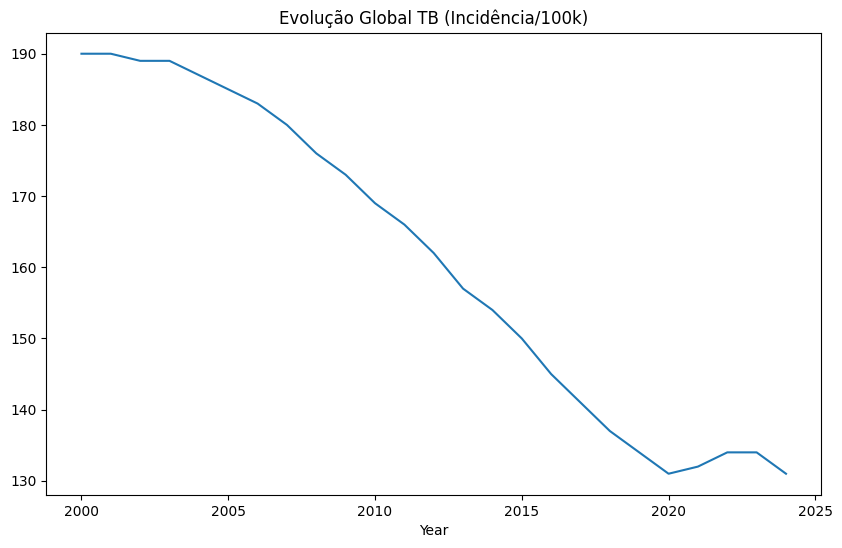

In [27]:
# Tendência mundial
world_data = df_analysis[df_analysis['Country Name'] == 'World']
world_trend = world_data.set_index('Year')['incidence_per_100k']
world_trend.plot(title="Evolução Global TB (Incidência/100k)", figsize=(10,6))

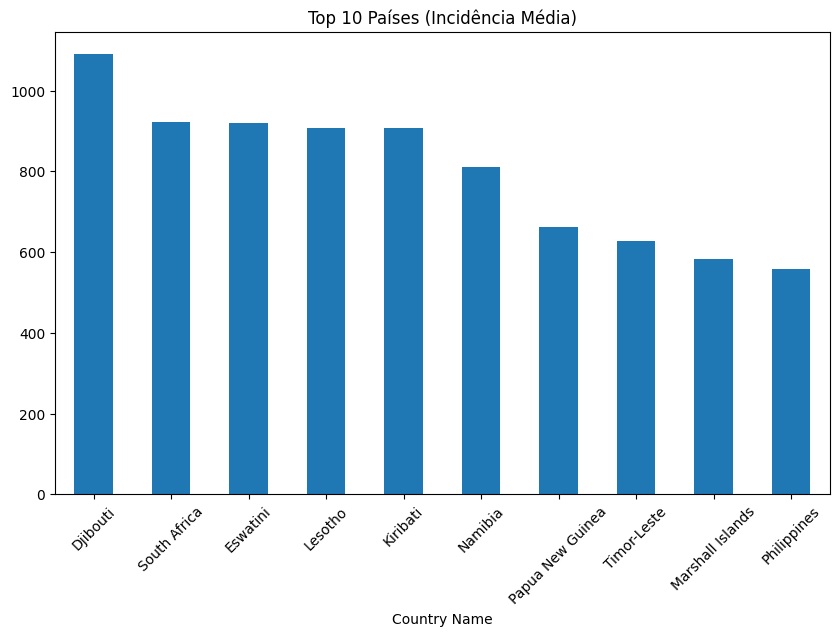

In [28]:
#Top 10 países com maior incidência média
top10 = df_analysis.groupby('Country Name')['incidence_per_100k'].mean().nlargest(10)
top10.plot(kind='bar', title="Top 10 Países (Incidência Média)", figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

In [39]:
# Crição da coluna de Variação anual %
df_analysis['var_annual_pct'] = df_analysis.groupby('Country Name')['incidence_per_100k'].pct_change() * 100

df_analysis.head()

,Country Name,Country Code,Year,incidence_per_100k,var_annual_pct
0,Afghanistan,AFG,2000,148.0,<NA>
1,Afghanistan,AFG,2001,175.0,18.243243
2,Afghanistan,AFG,2002,197.0,12.571429
3,Afghanistan,AFG,2003,215.0,9.137056
4,Afghanistan,AFG,2004,228.0,6.046512


In [40]:
# Criação da coluna de variação 5 anos absoluta
df_analysis['var_5y_abs'] = df_analysis.groupby('Country Name')['incidence_per_100k'].diff(5)
df_analysis.head()

,Country Name,Country Code,Year,incidence_per_100k,var_annual_pct,var_5y_abs
0,Afghanistan,AFG,2000,148.0,<NA>,<NA>
1,Afghanistan,AFG,2001,175.0,18.243243,<NA>
2,Afghanistan,AFG,2002,197.0,12.571429,<NA>
3,Afghanistan,AFG,2003,215.0,9.137056,<NA>
4,Afghanistan,AFG,2004,228.0,6.046512,<NA>


In [46]:

#Converter NAN para 0 e forçar o tipo float64 para evitar problemas de dtype
df_analysis['var_5y_abs'] = df_analysis['var_5y_abs'].fillna(0).astype(float)

#Criar a coluna de status com base na variação 5 anos absoluta usando np.select para evitar problemas de dtype
df_analysis['controle_status'] = np.select(
    [
        df_analysis['var_5y_abs'] < -20,
        (df_analysis['var_5y_abs'] >= -20) & (df_analysis['var_5y_abs'] < 0),
        (df_analysis['var_5y_abs'] >= 0) & (df_analysis['var_5y_abs'] < 10),
        df_analysis['var_5y_abs'] >= 10
    ],
    ['Excelente', 'Melhorando', 'Estável', 'Piorando'],
    default='Sem dados'
)

In [47]:
df_analysis.head()

,Country Name,Country Code,Year,incidence_per_100k,var_annual_pct,var_5y_abs,controle_status
0,Afghanistan,AFG,2000,148.0,<NA>,0.0,Estável
1,Afghanistan,AFG,2001,175.0,18.243243,0.0,Estável
2,Afghanistan,AFG,2002,197.0,12.571429,0.0,Estável
3,Afghanistan,AFG,2003,215.0,9.137056,0.0,Estável
4,Afghanistan,AFG,2004,228.0,6.046512,0.0,Estável


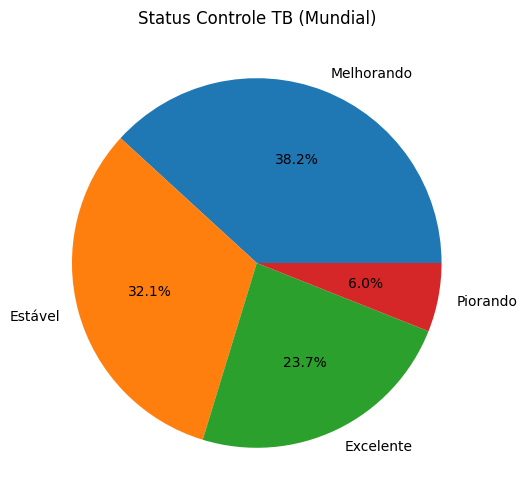

In [49]:
# Pizza Status
df_analysis['controle_status'].value_counts().plot(
    kind='pie', title="Status Controle TB (Mundial)", 
    autopct='%1.1f%%', figsize=(8,6)
)
plt.ylabel('')
plt.show()


# Salvar o df final

In [50]:
df_analysis.to_csv('../data/processed/tb_completo_com_metricas.csv', index=False)